# Traffic Flow Forecasting
Design a sequence prediction model using RNNs to forecast traffic density for smart city
applications

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

## Load Dataset

In [2]:
df = pd.read_csv("/content/traffic.csv")

print(df.head())

print(df.info())

              DateTime  Junction  Vehicles           ID
0  2015-11-01 00:00:00         1        15  20151101001
1  2015-11-01 01:00:00         1        13  20151101011
2  2015-11-01 02:00:00         1        10  20151101021
3  2015-11-01 03:00:00         1         7  20151101031
4  2015-11-01 04:00:00         1         9  20151101041
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None


## Data Preprocessing

In [3]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

df = df.sort_values('DateTime')

df.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
14592,2015-11-01 00:00:00,2,6,20151101002
29184,2015-11-01 00:00:00,3,9,20151101003
29185,2015-11-01 01:00:00,3,7,20151101013
1,2015-11-01 01:00:00,1,13,20151101011


## Feature Engineering

In [4]:
df['Hour'] = df['DateTime'].dt.hour
df['Day'] = df['DateTime'].dt.day
df['Month'] = df['DateTime'].dt.month
df['DayOfWeek'] = df['DateTime'].dt.dayofweek
df['Weekend'] = df['DayOfWeek'].isin([5,6]).astype(int)

df.head()

,DateTime,Junction,Vehicles,ID,Hour,Day,Month,DayOfWeek,Weekend
0,2015-11-01 00:00:00,1,15,20151101001,0,1,11,6,1
14592,2015-11-01 00:00:00,2,6,20151101002,0,1,11,6,1
29184,2015-11-01 00:00:00,3,9,20151101003,0,1,11,6,1
29185,2015-11-01 01:00:00,3,7,20151101013,1,1,11,6,1
1,2015-11-01 01:00:00,1,13,20151101011,1,1,11,6,1


## Missing Values

In [5]:
print(df.isnull().sum())

DateTime     0
Junction     0
Vehicles     0
ID           0
Hour         0
Day          0
Month        0
DayOfWeek    0
Weekend      0
dtype: int64


## Exploratory Data Analysis

In [6]:
print(df.describe())

                            DateTime      Junction      Vehicles  \
count                          48120  48120.000000  48120.000000   
mean   2016-09-19 06:03:56.109725696      2.180549     22.791334   
min              2015-11-01 00:00:00      1.000000      1.000000   
25%              2016-04-16 01:45:00      1.000000      9.000000   
50%              2016-09-30 03:30:00      2.000000     15.000000   
75%              2017-02-25 16:00:00      3.000000     29.000000   
max              2017-06-30 23:00:00      4.000000    180.000000   
std                              NaN      0.966955     20.750063   

                 ID          Hour           Day         Month     DayOfWeek  \
count  4.812000e+04  48120.000000  48120.000000  48120.000000  48120.000000   
mean   2.016330e+10     11.500000     15.700748      5.884289      2.996010   
min    2.015110e+10      0.000000      1.000000      1.000000      0.000000   
25%    2.016042e+10      5.750000      8.000000      3.000000      1.00

## Traffic Trend

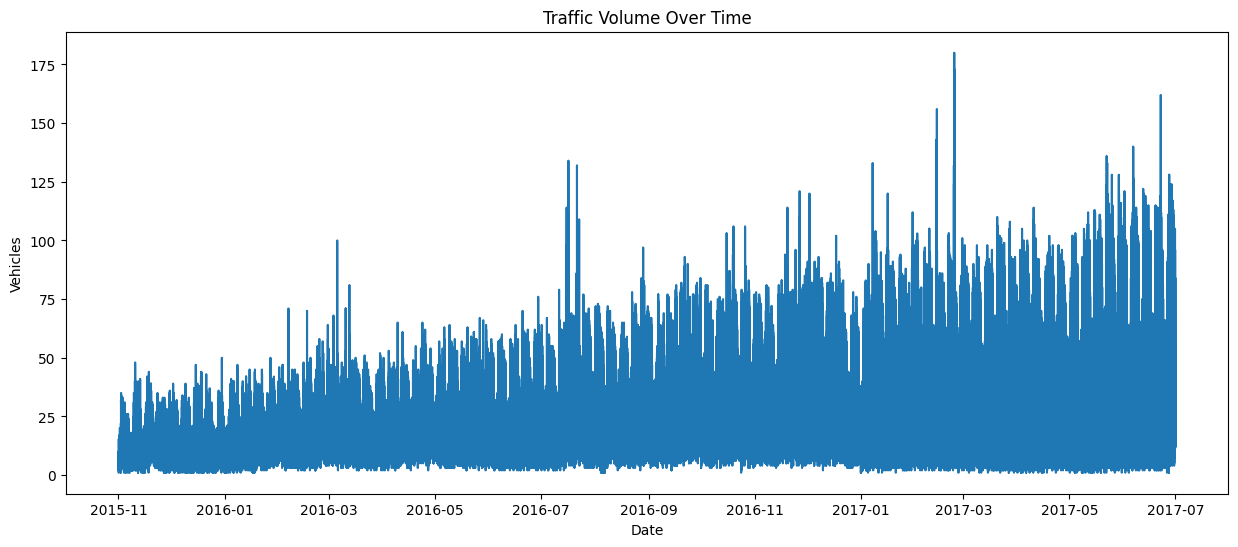

In [7]:
plt.figure(figsize=(15,6))

plt.plot(df['DateTime'], df['Vehicles'])

plt.title("Traffic Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Vehicles")

plt.show()

## Vehicles Distribution

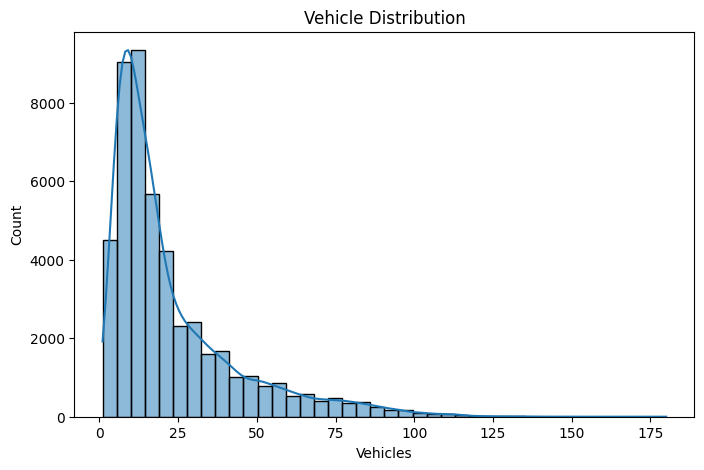

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['Vehicles'], bins=40, kde=True)

plt.title("Vehicle Distribution")

plt.show()

## Box Plot: To detect outliers

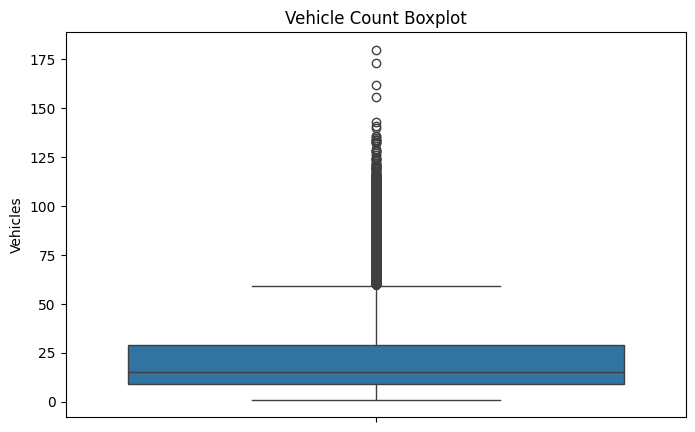

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df['Vehicles'])

plt.title("Vehicle Count Boxplot")

plt.show()

## Average Traffic by Hour

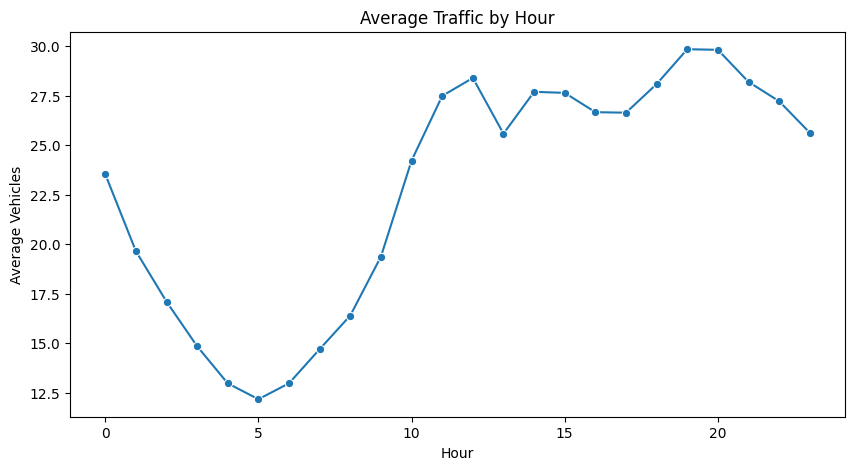

In [10]:
hourly_traffic = df.groupby('Hour')['Vehicles'].mean()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=hourly_traffic.index,
    y=hourly_traffic.values,
    marker='o'
)

plt.title("Average Traffic by Hour")

plt.xlabel("Hour")
plt.ylabel("Average Vehicles")

plt.show()

## Correlation Heatmap

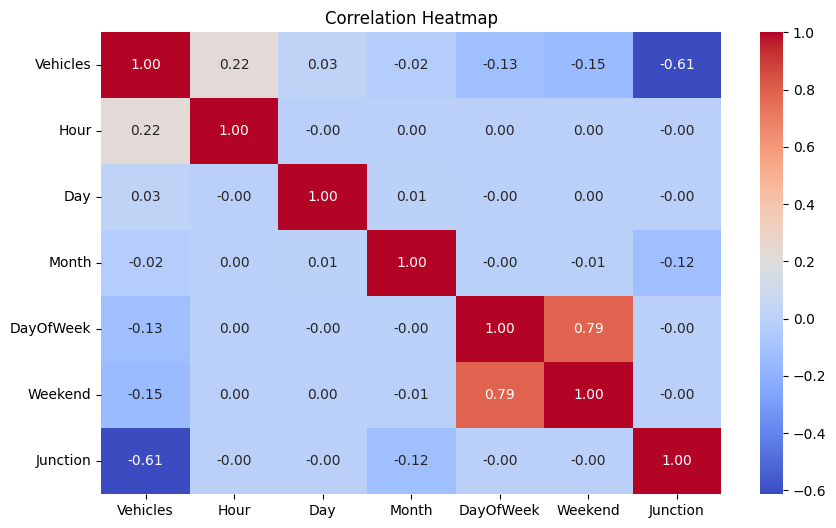

In [11]:
corr_features = [
    'Vehicles',
    'Hour',
    'Day',
    'Month',
    'DayOfWeek',
    'Weekend',
    'Junction'
]

plt.figure(figsize=(10,6))

sns.heatmap(
    df[corr_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

## Preparing Data for RNN

In [12]:
traffic = df['Vehicles'].values.reshape(-1,1)

scaler = MinMaxScaler()

traffic_scaled = scaler.fit_transform(traffic)

## Creating Sequences

In [13]:
def create_sequences(data, sequence_length):

    X = []
    y = []

    for i in range(len(data) - sequence_length):

        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])

    return np.array(X), np.array(y)


sequence_length = 24

X, y = create_sequences(
    traffic_scaled,
    sequence_length
)

print(X.shape)
print(y.shape)

(48096, 24, 1)
(48096, 1)


## Train Test Split

In [14]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(X_train.shape)
print(X_test.shape)

(38476, 24, 1)
(9620, 24, 1)


Building RNN Model

In [15]:
model = Sequential()

model.add(
    SimpleRNN(
        units=64,
        activation='tanh',
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(Dropout(0.2))

model.add(
    SimpleRNN(
        units=32
    )
)

model.add(Dropout(0.2))

model.add(Dense(16, activation='relu'))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 24, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,873 (30.75 KB)

 Trainable params: 7,873 (30.75 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - loss: 0.0099 - val_loss: 0.0177
Epoch 2/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0078 - val_loss: 0.0166
Epoch 3/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - loss: 0.0075 - val_loss: 0.0163
Epoch 4/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0073 - val_loss: 0.0166
Epoch 5/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - loss: 0.0072 - val_loss: 0.0162
Epoch 6/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - loss: 0.0071 - val_loss: 0.0167
Epoch 7/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - loss: 0.0070 - val_loss: 0.0172
Epoch 8/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - loss: 0.0069 - val_loss: 0.0159
Epoch 9/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 0.0069 - val_loss: 0.0165
Epoch 10/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - loss: 0.0068 - val_loss: 0.0162
Epoch 11/30
542/542 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - loss: 0.0068 - val_loss: 0.0158
Epoch 12/30
542/542 ━━━━━━━━━━

## Learning Curve

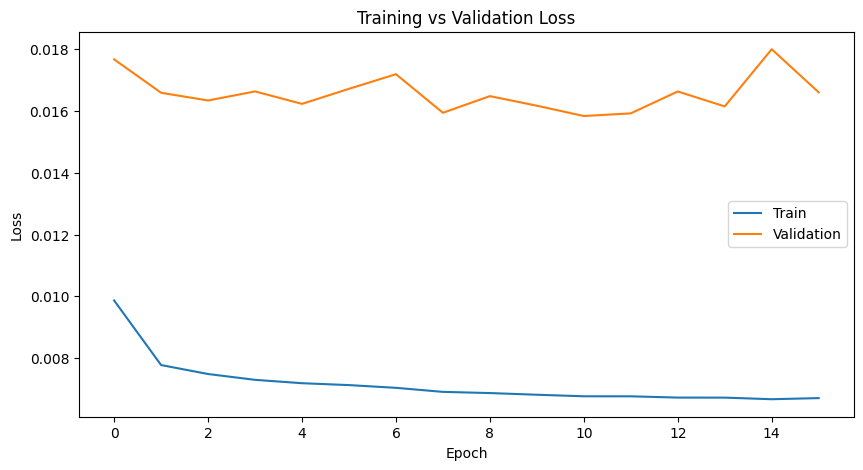

In [17]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train','Validation'])

plt.show()

## Predictions

In [18]:
predictions = model.predict(X_test)

301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


## Inverse Scaling

In [19]:
predictions = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(y_test)

## Actual vs Predicted Graph

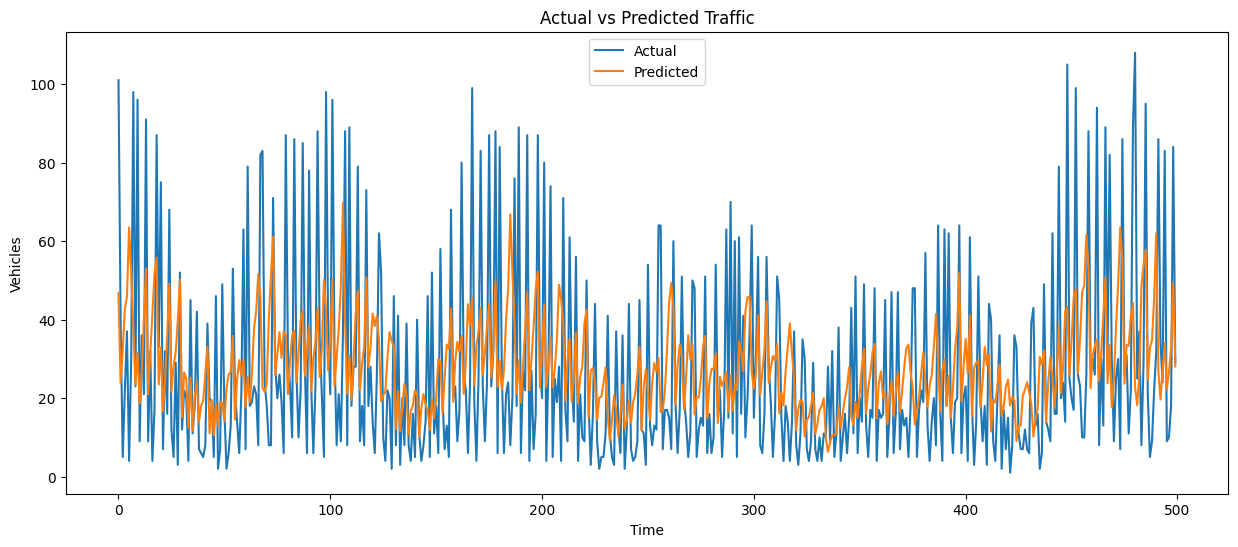

In [20]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test_actual[:500],
    label='Actual'
)

plt.plot(
    predictions[:500],
    label='Predicted'
)

plt.title("Actual vs Predicted Traffic")

plt.xlabel("Time")

plt.ylabel("Vehicles")

plt.legend()

plt.show()

## Model Evaluation

### 1. MAE

In [21]:
mae = mean_absolute_error(
    y_test_actual,
    predictions
)

print("MAE:", mae)

MAE: 19.050964848514408


### 2. MSE

In [22]:
mse = mean_squared_error(
    y_test_actual,
    predictions
)

print("MSE:", mse)

MSE: 621.542474347076


### 3. RMSE

In [23]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 24.93075358562344


### 4. R-Sqaure Score

In [24]:
r2 = r2_score(
    y_test_actual,
    predictions
)

print("R2 Score:", r2)

R2 Score: 0.161255222435024


### 5. MAPE : Commonly used for forecasting

In [25]:
mape = np.mean(
    np.abs(
        (y_test_actual - predictions)
        / y_test_actual
    )
) * 100

print("MAPE:", mape)

MAPE: 140.64115250225754


## Forecast for Next 24 Hours

In [26]:
last_sequence = traffic_scaled[-24:]

future_predictions = []

current_sequence = last_sequence.copy()

for _ in range(24):

    pred = model.predict(
        current_sequence.reshape(1,24,1),
        verbose=0
    )

    future_predictions.append(pred[0,0])

    current_sequence = np.append(
        current_sequence[1:],
        pred
    )

future_predictions = np.array(future_predictions).reshape(-1,1)

future_predictions = scaler.inverse_transform(
    future_predictions
)

print("Next 24 Hours Forecast")

print(future_predictions)

Next 24 Hours Forecast
[[45.818768 ]
 [54.11152  ]
 [24.107635 ]
 [23.956036 ]
 [41.958946 ]
 [20.563137 ]
 [22.684471 ]
 [38.95482  ]
 [18.682093 ]
 [21.156424 ]
 [30.585945 ]
 [16.418615 ]
 [16.474463 ]
 [22.254658 ]
 [13.622465 ]
 [12.448609 ]
 [15.3440695]
 [11.264857 ]
 [ 8.173238 ]
 [ 9.124989 ]
 [ 8.805711 ]
 [ 5.485727 ]
 [ 5.092642 ]
 [ 4.682923 ]]


## Future Traffic Forecast Graph

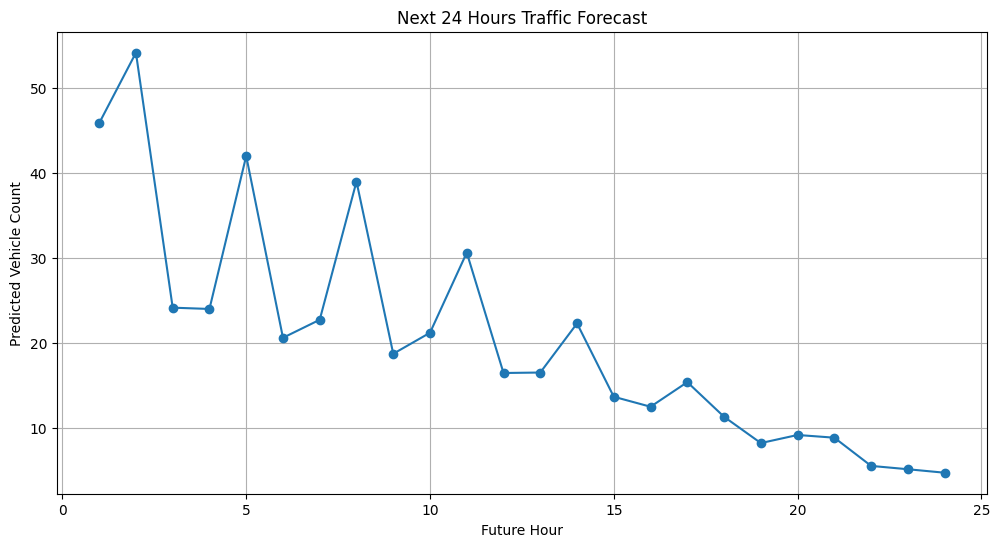

In [27]:
future_hours = np.arange(1,25)

plt.figure(figsize=(12,6))

plt.plot(
    future_hours,
    future_predictions,
    marker='o'
)

plt.title("Next 24 Hours Traffic Forecast")

plt.xlabel("Future Hour")
plt.ylabel("Predicted Vehicle Count")

plt.grid(True)

plt.show()

## Model Summary

- The model achieved an MAE of 19.05 vehicles and an RMSE of 24.93 vehicles, indicating moderate prediction accuracy.
- The R² Score of 0.161 shows that the model captured a limited portion of the traffic variability present in the dataset.
- The high MAPE value (140.64%) suggests significant prediction errors for low traffic-count observations.
- The model successfully learned basic traffic patterns but requires further optimization for improved forecasting performance.
- Future improvements may include feature engineering, hyperparameter tuning, the use of LSTM/GRU architectures, and incorporation of external factors such as weather conditions and special events.